In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
# Load the data
data = pd.read_excel('DataHFT/BondHFTData.xlsx')

# Convert the date column to a datetime object
data['Date'] = pd.to_datetime(data['Date'])

# Set the date column as the index
data.set_index('Date', inplace=True)
data.head()


,Unnamed: 0,Price
Date,,
2024-09-04 15:39:57.340,0,4.129
2024-09-04 15:39:58.383,1,4.129
2024-09-04 15:39:59.397,2,4.129
2024-09-04 15:40:00.414,3,4.129
2024-09-04 15:40:01.431,4,4.129


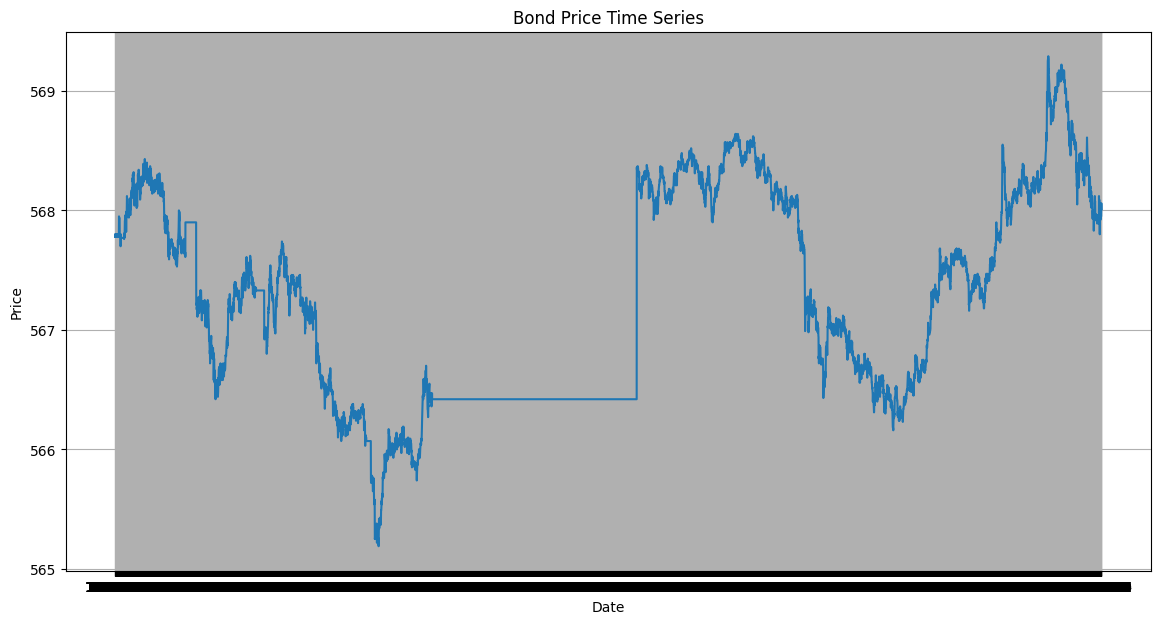

<Figure size 640x480 with 0 Axes>

In [9]:
# Load the data
data = pd.read_excel('DataHFT/SPYHFTData.xlsx')

# Convert the date column to a datetime object
data['Date'] = pd.to_datetime(data['Date'])

# Set the date column as the index
data.set_index('Date', inplace=True)
data.head()
# Plot the time series data
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Price'])
plt.title('Bond Price Time Series')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

plt.tight_layout()
plt.show()


In [4]:
import statsmodels.api as sm
def halfLife(close:pd.Series):
    z_array = close
    z_lag = np.roll(z_array,1)
    z_lag[0] = 0
    z_ret = z_array - z_lag
    z_ret[0] = 0

    #adds intercept terms to X variable for regression
    z_lag2 = sm.add_constant(z_lag)

    model = sm.OLS(z_ret,z_lag2)
    res = model.fit()

    halflife = -np.log(2) / res.params[1]
    return f"time to reverting to the mean in seconds: {halflife.real/(30*60*24) :.4f} and the mean return is {close.mean() :.4f}%"

In [5]:
from statsmodels.tsa.stattools import adfuller
print(adfuller(data['Price'])[1])

0.1638281057255917


In [6]:
print(halfLife(data['Price']))

time to reverting to the mean in seconds: 0.3397 and the mean return is 4.0189%


Autocorrelation Function (ACF)
- What is ACF? The ACF measures the correlation between time series observations at different lags. In simpler terms, it expresses how well the current value of the series is related to its past values.
- Significance: ACF is used to identify the moving average component of an ARIMA model, denoted as (q). It shows the extent of correlation between a variable and its lag across successive time intervals. If the ACF shows a gradual decline, it suggests a moving average process might be suitable.

Partial Autocorrelation Function (PACF)
- What is PACF? The PACF measures the correlation between observations at two points in time, controlling for the values at all shorter lags. It isolates the effect of intervening time points.
- Significance: PACF is primarily used to determine the order of the autoregressive component of an ARIMA model, denoted as (p). A sharp cut-off in the PACF after a certain number of lags suggests the order of the AR process.

Application in Time Series Analysis
- Differencing: Before plotting ACF and PACF, the series should be made stationary. This often involves differencing the series, where each value is subtracted from its previous value, to remove trends and seasonality.
- Model Identification: By examining the patterns in the ACF and PACF plots, you can make informed decisions about the likely parameters for the ARIMA model. For example, if the PACF plot shows a significant spike at lag 2, followed by non-significant spikes, this suggests an $\operatorname{AR}(2)$ model might be appropriate.

These plots provide a visual insight into the data which can guide the specification of your time series model, improving the model's accuracy and predictive power.

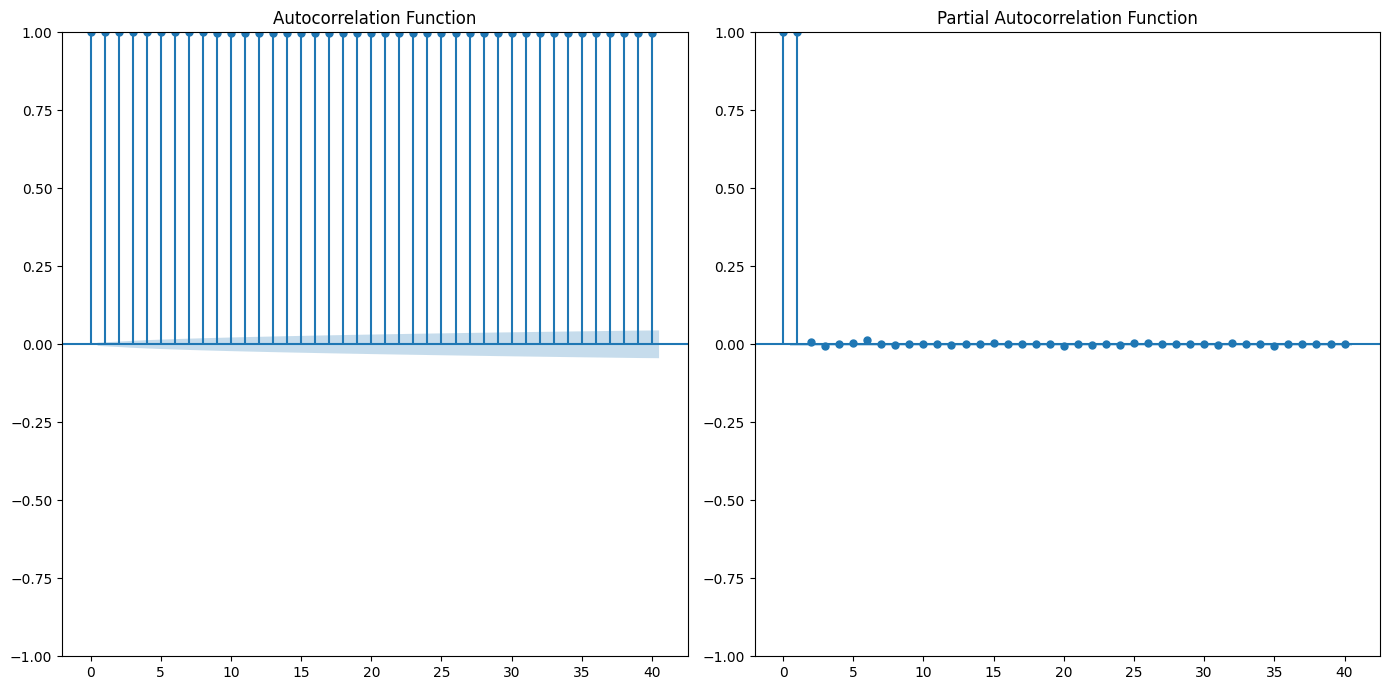

In [26]:
# Importing neccessary module from statsmodels library
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# To accurately map the acf and pacf, we need a stationary series
# Plotting ACF
plt.figure(figsize=(14, 7))
plt.subplot(121) # 1 row, 2 columns, 1st subplot
plot_acf(data['Price'], ax=plt.gca(), lags=40)
plt.title('Autocorrelation Function')
# Plotting PACF
plt.subplot(122) # 1 row, 2 columns, 2nd subplot
plot_pacf(data['Price'], ax=plt.gca(), lags=40)
plt.title('Partial Autocorrelation Function')
plt.tight_layout()
plt.show()

We can compare the AIC score of the models with different $p, q$ and $d$ values. The best fit model would be the one with the lowest AIC score.

## Modeling time series using ARIMA models
The ARIMA (AutoRegressive Integrated Moving Average) class of models is a popular statistical technique in time series forecasting. It exploits different standard temporal structures seen in time series processes.

Exponential smoothing and ARIMA models are the two most widely used approaches to time series forecasting, and provide complementary approaches to the problem. While exponential smoothing models are based on a description of the trend and seasonality in the data, ARIMA models aim to describe the autocorrelations in the data.

Overview on ARIMA
We will now take a brief look at its key features by taking apart the acronym.
1. Auto Regressive (AR):
- Regression of a time series process onto itself (its past versions)
- A time series process is $A R$ if its present value depends on a linear combination of past observations.
- In financial time series, an $A R$ model attempts to explain the mean reversion and trending behaviours that we observe in asset prices.
1. Integrated (I):

For a time series process $X_t$ recorded at regular intervals, the difference operation is defined as
The difference operator (denoted by $\nabla$ ) can be applied repeatedly. For example,

$$
\nabla^2 X_t=\nabla X_t-\nabla X_{t-1}
$$

- A time series process is integrated of order $d$ (denoted by $I(d)$ ), if differencing the observations $d$ times, makes the process stationary.
1. Moving Average (MA):
- A time series process is $M A$ if its present value can be written as a linear combination of past error terms.
- $\quad M A$ models try to capture the idiosyncratic shocks observed in financial markets. We can think of events like terrorist attacks, earnings surprises, sudden political changes, etc. as the random shocks affecting the asset price movements.

When we use the ARIMA class to model a time series process, each of the above components are specified in the model as parameters (with the notations $p, d$, and $q$ respectively).
That is, the classification $A R I M A(p, d, q)$ process can be thought of as

$$
A R(p) I(d) M A(q)
$$


Here,
1. $p$ : The number of past observations (we usually call them lagged terms) of the process included in the model.
2. $d$ : The number of times we difference the original process to make it stationary.
3. $q$ : The number of past error terms (we usually call them lagged error terms or lagged residuals) of the process included in the model.

When we model our time series process with the ARIMA class, we implicitly assume that the underlying data generating process (and by extension the observations we record) is an ARIMA process.

We should validate our assumptions (especially the implicit ones which slip under the radar) and recognize the limitations of our models. A well-known deficiency of ARIMA applications on financial time series is its failure to capture the phenomenon of volatility clustering. However, despite their inaccurate point estimates, they give rise to informative confidence intervals.

All of the below models would have good explanatory and predictive power only if the process is stationary.

$$
\begin{gathered}
A R(1): X_t=\phi X_{t-1}+\epsilon_t \\
M A(1): X_t=\epsilon_t+\theta \epsilon_{t-1} \\
A R(p): X_t=\phi_1 X_{t-1}+\phi_2 X_{t-2}+\ldots+\phi_p X_{t-p}+\epsilon_t \\
ARMA (p, q): X_t=\phi_1 X_{t-1}+\phi_2 X_{t-2}+\ldots+\phi_p X_{t-p}+\epsilon_t+\theta_1 \epsilon_{t-1}+\ldots+\theta_q \epsilon_{t-q}
\end{gathered}
$$


In [13]:
# Splitting the data into train and test that we can use the test data
#to evaluate our chosen model
split = int(len(data)*0.8)
data_train = data[:split]
data_test = data[split:]
print(data_train.shape[0], data_test.shape[0])
print(data_test.tail())

112871 28218
                         Unnamed: 0  Price
Date                                      
2024-09-18 21:38:48.642      141084  4.008
2024-09-18 21:38:50.661      141085  4.008
2024-09-18 21:38:52.681      141086  4.008
2024-09-18 21:38:54.701      141087  4.008
2024-09-18 21:38:56.731      141088  4.008


In [17]:
import pmdarima as pm
import warnings

def find_best_arima_parameters(data_series, seasonal=False, m=1):
    """
    Finds the best ARIMA parameters for the given time series data
    using auto_arima from pmdarima.
    Parameters:
    - data_series (pd.Series): Pandas Series containing the time
    series data.
    - seasonal (bool): Whether to consider seasonal differencing.
    - m (int): The number of periods in each season (relevant if
    seasonal is True).
    Returns:
    - tuple: The best (p, d, q) parameters for the ARIMA model.
    """
    # Ignoring warnings
    warnings.filterwarnings('ignore')
    # Performing the auto ARIMA process
    model = pm.auto_arima(data_series, seasonal=seasonal, m=m,
    trace=True, error_action='ignore',
    suppress_warnings=True)
    # Extracting the best ARIMA order
    best_order = model.order # This gives (p, d, q)
    # Optionally, print the summary of the best model
    print(model.summary())
    return best_order

In [18]:
best_param = find_best_arima_parameters(data_train['Price'])
print("Best ARIMA parameters (p, d, q):", best_param)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-1480245.421, Time=22.42 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-1480209.146, Time=8.22 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-1480215.732, Time=10.61 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-1480215.434, Time=13.35 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-1480209.412, Time=2.99 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-1480247.422, Time=19.46 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-1480249.421, Time=17.19 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-1480247.425, Time=25.96 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-1480226.062, Time=22.22 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-1480245.414, Time=24.70 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-1480249.708, Time=6.34 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-1480215.670, Time=5.03 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-1480247.710, Time=7.78 sec
 ARIMA(0,1,3)(0,0,0)[0]             : A

## Forecast Prices
We will now create a function to apply the ARIMA model with the selected parameters on the close price data

In [19]:
def get_predicted_prices(close_prices, best_param,steps:int):
    # Defining the best model
    best_model = ARIMA(close_prices.values, order=best_param)
    best_model_fit = best_model.fit(method_kwargs={"warn_convergence":
    False})
    # Making forecast
    predictions = best_model_fit.forecast(steps=steps)[0]
    return predictions

In [21]:
# Assuming best_param has already been determined using the training
data
predictions = []
for i in range(len(data_test['Price'])):
    # Incrementally adding test data to simulate a rolling forecast
    current_data = pd.concat([data_train['Price'], data_test['Price'].iloc[:i]])
    next_pred = get_predicted_prices(current_data, best_param,steps=60*10)
    predictions.append(next_pred)
# Converting the predictions list to a DataFrame
predictions_df = pd.DataFrame(predictions,
columns=['predicted_price'])
predictions_df.index = data_test.index
print(predictions_df)

KeyboardInterrupt: 